# AI in Biology: A Self-Paced Activity
-Jayesh Bhagat

## Module 0 : Orientation and the AI/ML/DL/NLP scenario

**Learning Objective**: Understand where ML sits inside AI, and where this notebook sits inside a real bioinformatics workflow.

📘 **Concepts: AI vs ML vs DL vs NLP and Learning Types**

Artificial Intelligence (AI) is the broadest field, aiming to create machines that can perform tasks that typically require human intelligence. Think of it as the grand vision of making computers 'smart'.

Machine Learning (ML) is a subfield of AI where systems learn from data, identifying patterns and making decisions with minimal human intervention. Instead of explicitly programming every rule, you feed the machine data, and it learns the rules itself. For example, if you want a computer to identify different types of cells, instead of writing code for every cell feature, you'd show it many examples of each cell type, and it would learn to distinguish them.

Deep Learning (DL) is a specialized subfield of ML that uses neural networks with many layers (hence 'deep') to learn complex patterns. DL is particularly powerful for tasks involving images, text, and sequences, like identifying specific structures in microscopy images or understanding genetic sequences.

Natural Language Processing (NLP) is another subfield of AI focused on enabling computers to understand, interpret, and generate human language. In biology, this could involve extracting information from scientific papers or analyzing patient notes.

### Learning Paradigms in Machine Learning

Within ML, there are different ways machines learn:

*   **Supervised Learning**: This is like learning with a teacher. You provide the algorithm with a dataset where each example has a known 'label' or 'answer'. The algorithm learns to map inputs to these outputs. For instance, **classifying a tumor as benign or malignant based on patient data (e.g., genetic markers, imaging features)** is a supervised learning task. The 'teacher' (the dataset) tells the algorithm what a benign tumor looks like and what a malignant tumor looks like.

*   **Unsupervised Learning**: Here, the algorithm explores data to find hidden patterns or structures without any predefined labels. It's like finding natural groupings in data without being told what those groups should be. An example is **clustering gene expression profiles from different samples to identify novel disease subtypes**. You don't tell the algorithm which samples belong to which subtype; it discovers the groupings itself.

*   **Reinforcement Learning (RL)**: This involves an 'agent' learning to make decisions by interacting with an 'environment' and receiving rewards or penalties for its actions. It's like training a pet with treats. For our purposes, consider **optimizing a bioreactor feed schedule to maximize a desired product yield**. The agent (the control system) tries different feed rates, and if the yield increases, it gets a 'reward' and learns to repeat that action. If the yield decreases, it gets a 'penalty' and learns to avoid that action. This iterative process helps find the optimal strategy over time.

✅ **Checkpoint: Classifying Biological Tasks**

Imagine you are developing an AI system to analyze microscopy images of blood samples. If the goal is to automatically categorize unknown cells into predefined types (e.g., 'red blood cell', 'white blood cell', 'platelet'), would this primarily be a **supervised** or **unsupervised** learning task? Explain your reasoning.

Your Answer here:


? **Why this matters in biology**

Supervised and unsupervised learning are fundamental to many bioinformatics tasks. Supervised models can diagnose diseases, predict drug efficacy, or identify functional elements in a genome. Unsupervised methods are crucial for discovering novel biological classifications, understanding complex molecular interactions, and reducing the dimensionality of high-throughput experimental data like transcriptomics, which often involves thousands of gene measurements per sample. Reinforcement learning, while less common in mainstream bioinformatics today, holds promise for optimizing experimental design, developing adaptive therapeutic strategies, or controlling bioprocesses.

🎯 **Critical Thinking: RL in the Lab**

Can you think of another hypothetical scenario in a biology lab where **Reinforcement Learning** might be applied, similar to the bioreactor example? Describe the 'agent', the 'environment', and the 'reward' in your scenario.

🎯 **Task: Run the Environment Check**

Before we dive into the data, let's ensure our environment is set up correctly and verify the versions of the libraries we'll be using. This step is crucial for reproducibility and ensuring that all subsequent code runs as expected. Run the cell below to perform the environment check.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

print("\nEnvironment check complete!")

Pandas version: 2.2.2
Numpy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1

Environment check complete!


✅ **Checkpoint: Understanding Learning Types**

In your own words, is predicting disease risk from a genetic profile supervised or unsupervised, and why?

*Your Answer Here:*

## Module 1 — Meet Your Data (EDA)

**Learning Objective**: Learn to look at data before modeling it.

📘 **Concepts: Features, Samples, Labels, and Data Messiness**

Before we jump into any machine learning algorithm, the very first step is to get to know your data. This process is called **Exploratory Data Analysis (EDA)**. Think of it as a biologist examining a new specimen under a microscope before performing an experiment.

### Key Data Components:

*   **Samples (or Observations)**: These are the individual items or instances in your dataset. In biology, a sample could be a single patient, a specific cell culture, a plant, or a gene sequence. Each row in a typical dataset often represents a sample.

*   **Features (or Attributes/Variables)**: These are the measurable properties or characteristics of each sample. For a patient, features might include age, blood pressure, genetic markers, or presence of a specific protein. Each column in a dataset often represents a feature.

*   **Labels (or Targets/Responses)**: In supervised learning, the label is the specific outcome or category you are trying to predict. For example, if you're predicting disease risk, the label might be 'diseased' or 'healthy'. In the Iris dataset we'll use, the 'species' of the flower is the label we often want to predict.

### Data Types:

*   **Categorical Data**: Represents categories or groups. It can be nominal (no inherent order, e.g., 'red', 'green', 'blue' or 'species A', 'species B') or ordinal (has a natural order, e.g., 'small', 'medium', 'large' or 'low', 'medium', 'high' disease severity).
*   **Continuous Data**: Represents measurements on a continuous scale, allowing for infinite values within a given range (e.g., height, weight, gene expression levels, temperature).

### Why Biological Data is Often Messy:

Biological data, especially from experiments, is notoriously messy. This messiness is not a flaw, but a reflection of the complexity of living systems and experimental limitations. Common issues include:

*   **Missing Values**: Data points that were not recorded or are unavailable. This can happen due to experimental errors, lost samples, or incomplete patient records.
*   **Batch Effects**: Systematic technical variations introduced during data collection when samples are processed in different groups or batches (e.g., running samples on different days, using different reagent lots, or different technicians). These can introduce spurious differences that are not biologically meaningful.
*   **Noise**: Random variations or errors in measurements that obscure the true biological signal. Biological processes themselves are often inherently noisy, and instruments add further noise.

Understanding these characteristics is crucial for preparing data for machine learning, which we'll explore in the next module.

✅ **Checkpoint: Dissecting a Biological Dataset**

Consider a dataset containing information about different types of bacteria. Each row represents a bacterial strain, and the columns include: 'Growth Rate (OD600/hr)', 'Presence of Gene X (Yes/No)', 'Antibiotic Resistance Level (Low, Medium, High)', and 'Phylum'.

1.  Identify an example of a **sample**.
2.  Identify an example of a **categorical feature** (specify if nominal or ordinal).
3.  Identify an example of a **continuous feature**.
4.  If your goal was to predict 'Antibiotic Resistance Level' based on the other information, which would be the **label**?

? **Why this matters in biology**

Recognizing features, samples, and labels is the foundation for setting up any biological machine learning problem. For example, in single-cell RNA sequencing, each *cell* is a sample, and the expression level of each *gene* is a feature. The 'label' might be the cell type or condition you're trying to identify. Understanding messiness like batch effects is critical; ignoring them can lead to misleading biological conclusions or models that fail to generalize to new experimental data. Correctly identifying and handling missing values or noise is paramount before attempting to build models for drug discovery, patient stratification, or understanding molecular pathways.

### Dataset: Iris Flowers

We will start with the classic Iris dataset. This dataset contains 150 samples of iris flowers, each belonging to one of three species (setosa, versicolor, or virginica). For each flower, four features are measured: sepal length, sepal width, petal length, and petal width, all in centimeters. It's a perfect dataset for beginning EDA due to its simplicity and clear structure.

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for easier manipulation
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target_names[iris.target]

print("First 5 rows of the Iris dataset:")
print(iris_df.head())

print("\nBasic descriptive statistics:")
print(iris_df.describe())

print("\nDataset information (data types, non-null counts):")
iris_df.info()

First 5 rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Basic descriptive statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000  

🎯 **Critical Thinking: Iris Data Insights**

Looking at the output of `iris_df.describe()` and `iris_df.info()` for the Iris dataset:

1.  Which feature shows the highest standard deviation (`std`)? What might this imply about the variability of that feature across the Iris samples?
2.  Based on `df.info()`, are there any missing values in the Iris dataset? How can you tell?

🎯 **Predict→Run→Interpret: Pairplot for Feature Separation**

One of the best ways to understand relationships between features and how well they might separate classes is through a pairplot. A pairplot shows scatter plots for all pairs of features, and histograms for individual features. By coloring points by species, we can visually inspect which features (or combinations of two features) do the best job at distinguishing between the different Iris species.

Before running the pairplot below, *guess which pair of features will separate the three species most cleanly. Why do you think that?*

*Your Prediction:*

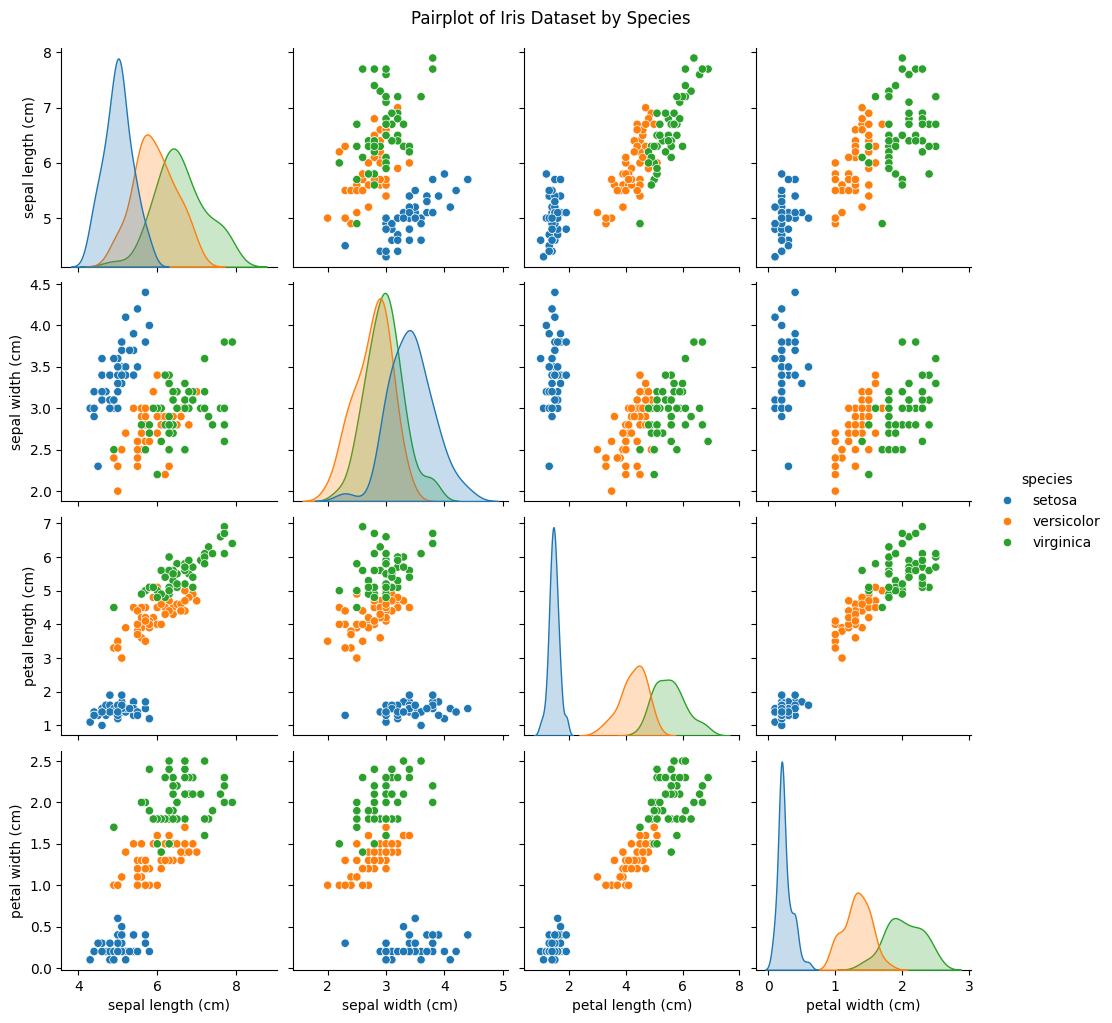

In [ ]:
# Run the pairplot
sns.pairplot(iris_df, hue='species', diag_kind='kde')
plt.suptitle('Pairplot of Iris Dataset by Species', y=1.02) # Adjust suptitle position
plt.show()

Now that you've run the pairplot, *were you right about which features separated the species best? Which two features (if any) seem to provide the clearest separation between all three species, just by looking at the plots?*

*Your Interpretation:*

✅ **Checkpoint: Worst Classifier Feature**

Which single feature alone would make the worst classifier for distinguishing between the three Iris species, and why?

*Your Answer Here:*

## Module 2 — Data Preprocessing

**Learning Objective**: Understand why raw data must be cleaned/scaled before ML.

📘 **Concepts: Cleaning and Scaling Data for Machine Learning**

Raw biological data is rarely in a perfect state for machine learning. Before feeding it into a model, we almost always need to preprocess it. This typically involves handling missing values, dealing with outliers, and scaling features.

### Handling Missing Values

Missing data can significantly affect model performance. Common strategies include:
*   **Imputation**: Filling in missing values with a substitute, such as the mean, median, or mode of the feature. More advanced methods exist, but these simple ones are a good starting point.
*   **Deletion**: Removing rows (samples) or columns (features) with missing values. This is often done if a large proportion of a sample's features are missing, or if a feature has too many missing values to be reliably imputed. However, it can lead to loss of valuable data.

### Normalization vs. Standardization

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. This is especially true for algorithms that rely on distance calculations (like k-NN or SVMs) or gradient descent (like neural networks).

*   **Normalization (Min-Max Scaling)**: Scales data to a fixed range, usually 0 to 1. This is useful when features have very different ranges and you want to ensure all features contribute equally to the distance calculations. The formula is: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

*   **Standardization (Z-score Normalization)**: Scales data to have a mean of 0 and a standard deviation of 1. This is often preferred when the data has a Gaussian (bell curve) distribution or when algorithms assume normally distributed data. It handles outliers better than normalization. The formula is: $X_{scaled} = \frac{X - \mu}{\sigma}$
    *   `StandardScaler` in scikit-learn is an example of standardization.
    *   `MinMaxScaler` in scikit-learn is an example of normalization.

### Train/Test Split and Data Leakage

🎯 **Why it must happen before fitting any scaler or model (Data Leakage Warning!)**

When preparing data, it's absolutely crucial to split your dataset into training and testing sets *before* performing any scaling or other preprocessing steps that learn parameters from the data (like calculating the mean or min/max for scaling).

⚠️ **Common mistake**: If you scale the *entire dataset* and then split it, information from your test set 'leaks' into the training process through the scaling parameters. This can make your model appear to perform better than it actually will on new, unseen data, giving you an overly optimistic evaluation. Always fit your scalers (and any other preprocessing transformers) *only* on the training data, and then apply that *same fitted scaler* to both the training and test sets.

✅ **Checkpoint: Scaling Scenarios**

Suppose you have a biological dataset where one feature is 'Cell Diameter (micrometers)' ranging from 5 to 50, and another is 'Gene Expression Level (counts)' ranging from 100 to 1,000,000.

1.  Would you prefer **Normalization (Min-Max Scaling)** or **Standardization (Z-score Normalization)** if you wanted to ensure both features contribute equally to a K-Nearest Neighbors algorithm, and why?
2.  If the 'Gene Expression Level' feature had a few extremely high outlier values, which scaling method (Min-Max or Standardization) would generally be more robust to these outliers?

🔬 **Why this matters in biology**

Biological datasets frequently suffer from missing values (e.g., failed assays, lost samples) and wide ranges in feature values (e.g., gene expression measured in counts vs. patient age in years). Ignoring missing data or unscaled features can lead to misleading biological insights or models that are biased towards features with larger numerical ranges. For example, if you're trying to predict disease outcome from gene expression data and clinical markers, a gene that varies from 0 to 100,000 counts will dominate a clinical marker like 'age' (0-100 years) unless the data is properly scaled. Careful preprocessing ensures that our machine learning models learn from the true biological signals, not from technical artifacts or arbitrary scale differences.

🎯 **Critical Thinking: The Cost of Unscaled Data**

In the context of predicting protein localization (e.g., 'cytoplasm', 'nucleus') based on various biochemical properties, what specific problems could arise if features like 'molecular weight' (large range) and 'pH value' (small range) are used directly in a machine learning model without proper scaling? How might this affect a distance-based algorithm like K-NN?

### Handling Missing Values (Detailed)

Handling missing values in a pandas DataFrame is a crucial step in data preprocessing. Here are some common strategies and how to implement them:

**Checking for Missing Values:**

*   `df.isnull()`: Returns a boolean DataFrame of the same shape as `df` indicating `True` where values are missing.
*   `df.isnull().sum()`: Returns a Series showing the count of missing values per column.
*   `df.isnull().sum().sum()`: Returns the total count of missing values in the entire DataFrame.
*   `df.info()`: Provides a concise summary of the DataFrame, including the number of non-null values per column.

**Dropping Missing Values:**

*   `df.dropna()`: Removes rows that contain any missing values. This is generally used when you have plenty of data and missing values are sparse, or when a row with missing data is not useful.
*   `df.dropna(axis=1)`: Removes columns that contain any missing values. Useful if a column is mostly empty.
*   `df.dropna(thresh=n)`: Drops rows that have less than `n` non-NaN values. You can specify a minimum number of valid observations required to keep a row/column.
*   `df.dropna(subset=['column_name'])`: Drops rows where missing values exist only in specific columns.

**Imputing Missing Values (Filling them in):**

*   `df.fillna(value)`: Fills all missing values with a specified value.
    *   Example: `df.fillna(0)` fills all NaNs with 0.
*   **Mean Imputation**: Fills missing values with the mean of the column. Best for numerical data without extreme outliers.
    *   Example: `df['column_name'].fillna(df['column_name'].mean(), inplace=True)`
*   **Median Imputation**: Fills missing values with the median of the column. More robust to outliers than mean imputation.
    *   Example: `df['column_name'].fillna(df['column_name'].median(), inplace=True)`
*   **Mode Imputation**: Fills missing values with the most frequent value (mode) of the column. Often used for categorical data.
    *   Example: `df['column_name'].fillna(df['column_name'].mode()[0], inplace=True)` (Note: `mode()` can return multiple values, so `[0]` selects the first).
*   **Forward Fill (ffill)**: Propagates the last valid observation forward to next valid observation.
    *   Example: `df.fillna(method='ffill', inplace=True)`
*   **Backward Fill (bfill)**: Propagates the next valid observation backward to next valid observation.
    *   Example: `df.fillna(method='bfill', inplace=True)`

**Using Scikit-learn Imputers:**

For more sophisticated imputation strategies, `sklearn.impute.SimpleImputer` (for mean, median, most_frequent) or `sklearn.impute.IterativeImputer` (for multivariate imputation) can be used. Remember to fit these imputers only on your training data to avoid data leakage.

The best method depends on the nature of your data, the percentage of missing values, and the specific machine learning task you are performing. Always visualize your data and understand the reason for missingness before applying any strategy.

### Dataset: Breast Cancer Wisconsin (Diagnostic)

For this module, we will use the Breast Cancer Wisconsin (Diagnostic) dataset. This dataset contains features computed from digitized images of breast mass fine needle aspirates (FNAs), describing characteristics of the cell nuclei present in the image. It's a binary classification problem (malignant vs. benign) with features that exhibit significant scale disparities, making it excellent for demonstrating the importance of scaling.

**Features**: 30 features, such as `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`, and their 'standard error' and 'worst' (largest) values.
**Target**: Malignant (0) or Benign (1).

First 5 rows of the Breast Cancer dataset (features only):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  w

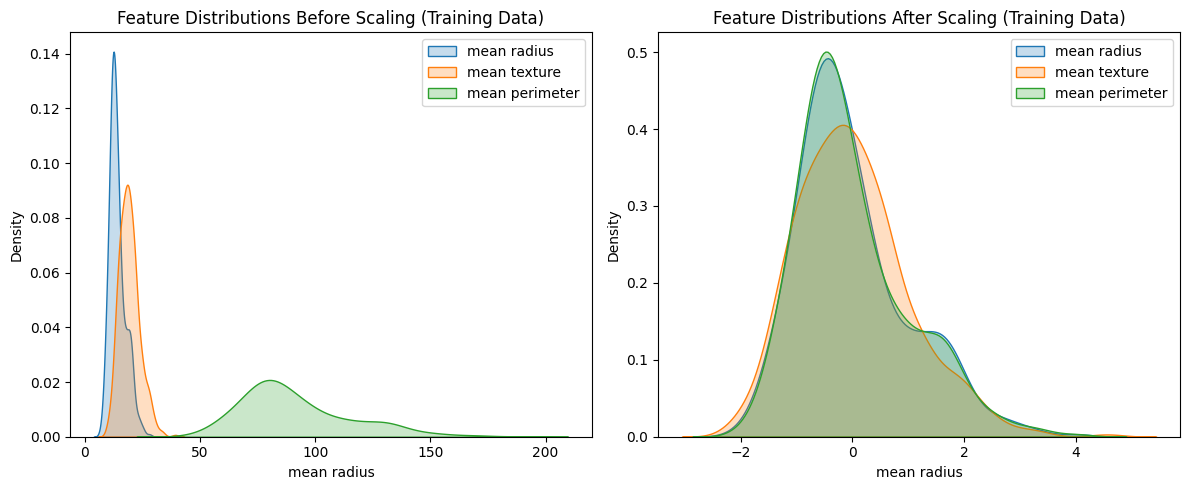

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Breast Cancer dataset
bc = load_breast_cancer()
bc_df = pd.DataFrame(data=bc.data, columns=bc.feature_names)
bc_df['target'] = bc.target

print("First 5 rows of the Breast Cancer dataset (features only):")
print(bc_df.head())

print("\nCheck for missing values:")
print(bc_df.isnull().sum().sum()) # Total number of missing values

# Separate features (X) and target (y)
X = bc_df.drop('target', axis=1)
y = bc_df['target']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Distribution of target in y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Distribution of target in y_test:\n{y_test.value_counts(normalize=True)}")

# Visualize feature distributions before scaling (first few features)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(X_train['mean radius'], label='mean radius', fill=True)
sns.kdeplot(X_train['mean texture'], label='mean texture', fill=True)
sns.kdeplot(X_train['mean perimeter'], label='mean perimeter', fill=True)
plt.title('Feature Distributions Before Scaling (Training Data)')
plt.legend()

# Standardize features using StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier visualization and future use
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Visualize feature distributions after scaling
plt.subplot(1, 2, 2)
sns.kdeplot(X_train_scaled_df['mean radius'], label='mean radius', fill=True)
sns.kdeplot(X_train_scaled_df['mean texture'], label='mean texture', fill=True)
sns.kdeplot(X_train_scaled_df['mean perimeter'], label='mean perimeter', fill=True)
plt.title('Feature Distributions After Scaling (Training Data)')
plt.legend()
plt.tight_layout()
plt.show()

✅ **Checkpoint: Data Leakage Scenario**

What would go wrong if we scaled the whole dataset *before* splitting into train/test, and why is this problematic for evaluating our model's real-world performance?

*Your Answer Here:*

---

## Review & Practice: Module 0 — Orientation & First Look at Data

### Summary of Module 0 Code

In Module 0, our primary task was to ensure the Python environment was correctly set up and to verify the versions of the libraries we would be using. This is a foundational step for reproducibility in any data science or machine learning project.

We imported essential libraries like `pandas`, `numpy`, `matplotlib`, `seaborn`, and `sklearn`. We then used the `__version__` attribute available on each library (or the main `matplotlib` module) to print their respective versions to the console. This confirmed that our environment met the necessary prerequisites.

In [ ]:
# Code from Module 0 (for review)
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

### Practice Test: Module 0

**Task**: Besides the libraries we already checked, it's often useful to know the Python version itself. Use the `sys` module to print the current Python version. If you haven't used `sys` before, you'll need to import it first.

In [ ]:
# Your code here: Import the 'sys' module and print the Python version

# Example of how to access version information (you need to figure out 'sys')
# print(f"Python version: {???}")

---

## Review & Practice: Module 1 — Meet Your Data (EDA)

### Summary of Module 1 Code

In Module 1, we focused on **Exploratory Data Analysis (EDA)** using the Iris dataset. The key steps involved:

1.  **Loading the Dataset**: We used `sklearn.datasets.load_iris()` to load the dataset and then converted it into a `pandas.DataFrame` for easier manipulation, adding the species names as a column.
    ```python
    from sklearn.datasets import load_iris
    import pandas as pd

    iris = load_iris()
    iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    iris_df['species'] = iris.target_names[iris.target]
    ```

2.  **Initial Data Inspection**: We used `df.head()` to view the first few rows, `df.describe()` for basic statistical summaries (mean, std, min, max, quartiles), and `df.info()` to check data types and identify any missing values.
    ```python
    print(iris_df.head())
    print(iris_df.describe())
    iris_df.info()
    ```

3.  **Visual Exploration with Pairplot**: We utilized `seaborn.pairplot()` to visualize the relationships between all pairs of features, colored by species. This helped us visually identify which features offered the best separation between the different flower species.
    ```python
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.pairplot(iris_df, hue='species', diag_kind='kde')
    plt.suptitle('Pairplot of Iris Dataset by Species', y=1.02)
    plt.show()
    ```

Module 1 emphasized the importance of understanding your data's structure, types, and inter-feature relationships before applying any complex models.

### Practice Test: Module 1

**Task**: Let's explore another aspect of the Iris dataset. Use `matplotlib.pyplot.hist` to plot histograms for each of the four numerical features (`sepal length (cm)`, `sepal width (cm)`, `petal length (cm)`, `petal width (cm)`). Plot them in a 2x2 grid. Add titles to each subplot to clearly label which feature is being displayed. This will help you understand the distribution of individual features.

In [ ]:
# Your code here: Create a 2x2 grid of histograms for the four Iris features
# You'll need to use plt.figure(), plt.subplot(), plt.hist(), and plt.title()

plt.figure(figsize=(10, 8))

# Subplot 1: Sepal Length
# plt.subplot(2, 2, 1)
# plt.hist(..., bins=10, edgecolor='black')
# plt.title('Sepal Length (cm)')

# ... continue for the other three features

plt.tight_layout()
plt.show()

### Summary of Module 2 Code

Module 2 focused on preparing data for machine learning, using the Breast Cancer dataset. The key techniques demonstrated were:

1.  **Loading and Initial Inspection**: We loaded the `load_breast_cancer` dataset from `sklearn.datasets`, converted it to a pandas DataFrame, and performed a quick check for missing values using `isnull().sum().sum()`.
    ```python
    from sklearn.datasets import load_breast_cancer
    import pandas as pd

    bc = load_breast_cancer()
    bc_df = pd.DataFrame(data=bc.data, columns=bc.feature_names)
    bc_df['target'] = bc.target
    # Check for missing values
    print(bc_df.isnull().sum().sum())
    ```

2.  **Train/Test Split**: We split the data into training and testing sets *before* any scaling to prevent data leakage, using `train_test_split`. We also used `stratify=y` to ensure the target variable's class distribution was similar in both sets.
    ```python
    from sklearn.model_selection import train_test_split

    X = bc_df.drop('target', axis=1)
    y = bc_df['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    ```
`X = bc_df.drop('target', axis=1)`: This line creates a new DataFrame called `X`. It takes the original `bc_df` DataFrame and removes the column named `'target' `. The `axis=1` argument specifies that we want to drop a column (as opposed to a row, which would be `axis=0`). In machine learning, `X` typically represents your **features** (also known as independent variables or predictors), which are the input data used to make predictions.

`y = bc_df['target']`: This line creates a new pandas Series called `y`. It selects only the `'target'` column from the original `bc_df` DataFrame. In machine learning, y typically represents your **target variable** (also known as the dependent variable or outcome), which is what you are trying to predict.

3.  **Feature Standardization**: We used `StandardScaler` to standardize the features, which transforms them to have a mean of 0 and a standard deviation of 1. Critically, the scaler was `fit` *only* on the training data (`X_train`) and then used to `transform` both the training (`X_train_scaled`) and test (`X_test_scaled`) sets.
    ```python
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train) # Fit and transform on training data
    X_test_scaled = scaler.transform(X_test)     # Transform test data using the *fitted* scaler
    ```

4.  **Visualization of Distributions**: Kernel Density Estimate (KDE) plots were used with `seaborn.kdeplot` to visualize the distribution of selected features before and after scaling, clearly showing the effect of standardization.
    ```python
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # (Code to create subplots and plot before and after scaling)
    # sns.kdeplot(X_train['mean radius'], ...)
    # sns.kdeplot(X_train_scaled_df['mean radius'], ...)
    plt.show()
    ```

This module highlighted the importance of preprocessing steps like scaling and the correct methodology for applying them, especially the critical role of performing train/test split *before* scaling to avoid data leakage.

---

## Review & Practice: Module 2 — Data Preprocessing

### Practice Test: Module 2

**Task**: In Module 2, we used `StandardScaler`. Now, let's practice using `MinMaxScaler` on the same Breast Cancer dataset. Your task is to:

1.  Initialize a `MinMaxScaler`.
2.  Fit it *only* on the `X_train` data.
3.  Transform both `X_train` and `X_test` using the fitted `MinMaxScaler`.
4.  Print the minimum and maximum values of a few features (e.g., `'mean radius'`, `'mean texture'`) from `X_train_minmax_scaled_df` to verify the scaling has worked correctly (they should be between 0 and 1).

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Assume X_train and X_test are already defined from previous cells
# (If you ran the module 2 code, these variables are available in the kernel)

# 1. Initialize a MinMaxScaler
minmax_scaler = MinMaxScaler()

# 2. Fit the scaler ONLY on X_train
minmax_scaler.fit(X_train)

# 3. Transform both X_train and X_test
X_train_minmax_scaled = minmax_scaler.transform(X_train)
X_test_minmax_scaled = minmax_scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection
X_train_minmax_scaled_df = pd.DataFrame(X_train_minmax_scaled, columns=X_train.columns)
X_test_minmax_scaled_df = pd.DataFrame(X_test_minmax_scaled, columns=X_test.columns)

# 4. Print min and max values for a few features from X_train_minmax_scaled_df
print("Min and Max values for 'mean radius' after Min-Max Scaling on training data:")
print(f"Min: {X_train_minmax_scaled_df['mean radius'].min():.4f}")
print(f"Max: {X_train_minmax_scaled_df['mean radius'].max():.4f}")

print("\nMin and Max values for 'mean texture' after Min-Max Scaling on training data:")
print(f"Min: {X_train_minmax_scaled_df['mean texture'].min():.4f}")
print(f"Max: {X_train_minmax_scaled_df['mean texture'].max():.4f}")

---

## Module 2.5 — Handling Missing Values: A Decision Framework

📘 **Concepts: Practical Decision-Making for Missing Values**

In Module 2, we learned *what* missing values are and *how* to handle them using methods like `dropna()` and `fillna()`, or `SimpleImputer`. Now, let's focus on the crucial **decision-making process**: when do you drop, and when do you impute? And if you impute, which method is best?

Here's a practical framework:

1.  **Detect and Quantify**:
    *   First, always identify where missing values exist (`df.isnull().sum()`) and their total count (`df.isnull().sum().sum()`).
    *   Calculate the *percentage* of missing values per column. This is often the most critical factor. For example, `df.isnull().sum() / len(df) * 100`.

2.  **Evaluate the Impact**:
    *   **Amount of Missing Data**:
        *   **Small percentage (e.g., <5%)**: You might consider dropping rows with missing data or imputing with simple strategies (mean, median, mode).
        *   **Moderate percentage (e.g., 5-30%)**: Imputation is generally preferred to retain data, but choose the imputation method carefully.
        *   **Large percentage (e.g., >30-50%)**: Consider if the column itself is useful. If so, advanced imputation might be needed, or consider dropping the column if it's too sparse.

    *   **Nature of the Data and Feature Importance**:
        *   **Numerical Data**: Mean or median imputation are common. Use median if the data is skewed or has outliers, as the median is more robust. Use mean if it's roughly symmetrically distributed.
        *   **Categorical Data**: Mode imputation is often used. You could also create a new category for 'Missing'.
        *   **Critical Features**: If a feature is known to be very important, you'll want to be careful with dropping it or using simplistic imputation. More advanced imputation (like using regression models to predict missing values) might be warranted.

    *   **Cause of Missingness**:
        *   **Missing At Random (MAR)**: The missingness is related to other observed variables. Simple imputation might be okay.
        *   **Missing Completely At Random (MCAR)**: The missingness is random and not related to any variables. Simple imputation is more likely to be valid.
        *   **Missing Not At Random (MNAR)**: The missingness is related to the value itself (e.g., patients with very high blood pressure are less likely to have it recorded). This is the most problematic, and simple imputation can introduce bias.

3.  **Choose a Strategy**:
    *   **Drop Rows (`dropna(axis=0)`)**: Use when the number of rows with missing values is small, and removing them doesn't significantly reduce your dataset size or introduce bias.
    *   **Drop Columns (`dropna(axis=1)`)**: Use when a column has a very high percentage of missing values, or if the feature is not deemed important enough to warrant complex imputation.
    *   **Impute (`fillna()` or `SimpleImputer`)**: This is generally preferred when you want to retain as much data as possible. Always apply imputation *after* the train/test split to prevent data leakage, fitting the imputer only on the training data.

This process often involves iterating and evaluating the impact of your chosen strategy on your model's performance. There's no one-size-fits-all answer, and domain knowledge is often key.

✅ **Checkpoint: Missing Values Strategy**

Imagine you have a dataset of patient genetic markers. One gene (`gene_X_expression`) has 80% missing values across all patients, while another (`patient_age`) has 5% missing values. You know `patient_age` is a crucial demographic feature.

1.  For `gene_X_expression`, would you prefer to **drop the column** or **impute** its missing values? Why?
2.  For `patient_age`, would you prefer to **drop rows with missing values** or **impute** them? If imputing, would you use the mean or median, and why?

*Your Answer Here:*

🎯 **Practice Test: Handling Missing Values in Breast Cancer Data**

You've been given a modified version of the Breast Cancer dataset (`bc_df_missing`) where some values have been deliberately removed to simulate real-world data imperfections.

Your task is to:

1.  **Inspect Missing Values**: Identify and quantify the missing values in `bc_df_missing`. Determine the total number of missing values and the percentage of missing values for each column.
2.  **Propose a Strategy**: Based on your inspection and the concepts discussed above, describe a strategy for handling missing values for each column that contains them. Justify your choices (e.g., why you chose to impute with the mean vs. median, or why you chose to drop a column).
3.  **Implement and Verify**: Implement your proposed strategy using appropriate pandas or scikit-learn functions. Verify that all missing values have been successfully handled.

**Note**: Assume that for this exercise, you don't need to perform a train/test split yet; you can work directly on `bc_df_missing`.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the original Breast Cancer dataset
bc = load_breast_cancer()
bc_df_missing = pd.DataFrame(data=bc.data, columns=bc.feature_names)
bc_df_missing['target'] = bc.target

# Artificially introduce missing values for the exercise
np.random.seed(42)
# Introduce 10% missing values in 'mean radius'
missing_indices_radius = np.random.choice(bc_df_missing.index, size=int(len(bc_df_missing) * 0.1), replace=False)
bc_df_missing.loc[missing_indices_radius, 'mean radius'] = np.nan

# Introduce 2% missing values in 'mean texture'
missing_indices_texture = np.random.choice(bc_df_missing.index, size=int(len(bc_df_missing) * 0.02), replace=False)
bc_df_missing.loc[missing_indices_texture, 'mean texture'] = np.nan

# Introduce 60% missing values in a new hypothetical 'gene_expression_marker' column
bc_df_missing['gene_expression_marker'] = np.random.rand(len(bc_df_missing)) * 100
missing_indices_gene = np.random.choice(bc_df_missing.index, size=int(len(bc_df_missing) * 0.6), replace=False)
bc_df_missing.loc[missing_indices_gene, 'gene_expression_marker'] = np.nan

# Your code here:
# 1. Inspect Missing Values
# 2. Propose a Strategy (in comments or markdown cells if you prefer)
# 3. Implement and Verify

---

## Module 3 — Feature Engineering & Dimensionality Reduction

**Learning Objective**: Reduce many correlated features into a few informative ones.

📘 **Concepts: Correlation, Multicollinearity, and PCA**

In many biological datasets, especially those derived from high-throughput technologies, we often end up with a very large number of features. Some of these features might be redundant, highly correlated, or simply not very informative. **Feature Engineering** is the process of creating new features or transforming existing ones to improve model performance or interpretability. **Dimensionality Reduction** is a type of feature engineering that aims to reduce the number of input variables in a dataset while retaining most of the important information.

### Correlation and Multicollinearity

*   **Correlation**: Measures the statistical relationship between two variables. If two features are highly positively correlated, they tend to increase or decrease together. If highly negatively correlated, one tends to increase as the other decreases.
*   **Multicollinearity**: Occurs when two or more independent features in a model are highly correlated with each other. This can be problematic for some machine learning models (e.g., linear regression), as it makes it difficult to determine the individual effect of each feature on the target variable.

### Principal Component Analysis (PCA)

**Principal Component Analysis (PCA)** is a powerful and widely used dimensionality reduction technique. Its main goal is to find new, uncorrelated variables (called **Principal Components, or PCs**) that capture as much of the variance in the original data as possible.

**Intuition**: Imagine your data points are scattered in a 3D space. PCA tries to find the 'best' 2D plane (or 1D line) onto which you can project these points such that the spread of the points is maximized on this new plane. This new plane (or line) is defined by the principal components.

*   **Variance Explained**: Each principal component explains a certain amount of the total variance in the dataset. The first principal component (PC1) captures the most variance, the second (PC2) captures the second most, and so on.
*   **Scree Plot**: A scree plot is a graph that shows the eigenvalues (which represent the amount of variance explained) for each principal component in decreasing order. It helps us decide how many principal components to keep by looking for an 'elbow' point where the explained variance drops off sharply.

### Feature Extraction vs. Feature Selection

*   **Feature Extraction**: Creates new, combined features from the original set. PCA is a form of feature extraction because it transforms the original features into a new set of principal components.
*   **Feature Selection**: Chooses a subset of the original features without transforming them. This might be done based on importance, correlation, or other criteria. Feature selection keeps the original meaning of the features, while feature extraction often creates abstract components.

🔬 **Why this matters in biology**

Dimensionality reduction techniques like PCA are indispensable in bioinformatics, especially when dealing with high-throughput data like gene expression matrices or proteomics. These datasets often contain thousands of genes or proteins (features) for a relatively small number of samples. Many genes might be highly correlated (e.g., co-expressed genes in a pathway), leading to multicollinearity. PCA can reduce these thousands of genes into a handful of principal components, each representing a combination of genes that captures a major source of variation in the data. This allows for:

*   **Visualization**: Plotting samples in the 2D space of PC1 and PC2 can reveal hidden clusters or relationships between samples (e.g., distinguishing disease subtypes or developmental stages) that would be impossible to see in thousands of dimensions.
*   **Noise Reduction**: By focusing on components that explain the most variance, PCA can effectively filter out noise, which often accounts for smaller variations.
*   **Computational Efficiency**: Reduces the computational burden for subsequent machine learning models.

Indeed, applying PCA to gene expression matrices is exactly this process, just with potentially thousands of genes instead of the 13 chemical measurements we will see in the Wine dataset.

### Dataset: Wine Recognition

For this module, we will use the Wine dataset. This dataset contains the results of a chemical analysis of wines grown in the same region in Italy but derived from three different cultivars. The analysis determined the quantities of 13 constituents found in each of the three types of wines. This dataset is excellent for demonstrating correlation and PCA because it has multiple numerical features and a clear target (wine cultivar) that we can observe how well the reduced dimensions separate.

In [ ]:
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Wine dataset
wine = load_wine()
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
wine_df['cultivar'] = wine.target

print("First 5 rows of the Wine dataset:")
print(wine_df.head())
# filter based on cultivar
print("\nBasic descriptive statistics for a few features:")
print(wine_df[['alcohol', 'malic_acid', 'flavanoids', 'proline']].describe())

# Separate features (X) and target (y)
X = wine_df.drop('cultivar', axis=1)
y = wine_df['cultivar']

# It's good practice to scale data before PCA, especially if features have different units/ranges
# We'll use StandardScaler here
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Task 1: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(X_scaled_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Wine Features (Scaled)')
plt.show()

# Task 2: Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("\nFirst 5 rows of the PCA-transformed dataset:")
print(X_pca)
print("\nFirst 5 rows of the PCA-transformed dataset with column names:")
print(pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]).head())
# Task 3: Plot cumulative explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Explained Variance')
plt.legend(loc='best')
plt.show()

# Task 4: Re-plot classes in PC1-PC2 space
# Create a DataFrame for the first two principal components
pca_df = pd.DataFrame(data=X_pca[:, 0:2], columns=['PC1', 'PC2'])
pca_df['cultivar'] = y

print("\nFirst 5 rows of the PCA-transformed dataset:")
print(pca_df.head())

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cultivar', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Wine Cultivars in PC1-PC2 Space')
plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% variance)')
plt.grid(True)
plt.show()


🎯 **Bonus: Interactive 3D Exploration with Plotly**The PC1-PC2 scatter above uses only the first two principal components. Since we computed all components, we can also look at PC3 to see if it separates cultivars that PC1/PC2 leave overlapping. The cell below builds an interactive 3D scatter plot (PC1, PC2, PC3) using Plotly -- drag to rotate it. This is optional and purely exploratory; it is not required to complete the module.

In [ ]:
import plotly.express as px

# 1. Convert your PCA array into a DataFrame (if you haven't already)
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# 2. Add your target/labels if you want to color-code the points (Optional)
df_pca['target'] = y

# 3. Create the 3D scatter plot
fig = px.scatter_3d(
    df_pca,
    x='PC1',
    y='PC2',
    z='PC3',
    color='target', # Uncomment this line to color code by a column
    title='3D PCA Plot (PC1 vs PC2 vs PC3)',
    labels={'PC1': 'PC1', 'PC2': 'PC2', 'PC3': 'PC3'}
)

# 4. Update marker size for better visibility
fig.update_traces(marker=dict(size=5, opacity=0.8))

# 5. Display the plot
fig.show()


🎯 **Bonus: PCA Biplot — Visualizing Feature Contributions**A biplot overlays the sample scatter (from PC1-PC2) with arrows showing how strongly each *original* feature contributes to each principal component. A long arrow pointing mostly along PC1 means that feature drives PC1; two arrows pointing in similar directions mean those features are correlated. This is how you translate an abstract 'PC1/PC2' axis back into biologically meaningful features -- e.g., in a gene expression PCA, the biplot arrows would be genes, telling you which genes drive the separation you see in the scatter plot.

In [ ]:
# Reuse the pca, X_pca, X, and y objects already created above -- no need to reload or refit
plt.figure(figsize=(12, 8))

# Scatter plot of samples (using the same PC1/PC2 computed earlier)
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cultivar',
    data=pca_df,
    palette='viridis',
    s=70,
    alpha=0.6
)

# Extract loadings (component coefficients) for PC1 and PC2 only
loadings = pca.components_[:2].T  # Shape: (n_features, 2)

# Scale factor to stretch vector arrows so they fit nicely with sample data
scale_factor = 3.5

# Plot loading vectors and labels
for i, feature in enumerate(X.columns):
    arrow_x = loadings[i, 0] * scale_factor
    arrow_y = loadings[i, 1] * scale_factor

    plt.arrow(0, 0, arrow_x, arrow_y, color='r', alpha=0.75, head_width=0.15, head_length=0.15)
    plt.text(arrow_x * 1.15, arrow_y * 1.15, feature, color='darkred', ha='center', va='center', fontsize=9)

plt.title('PCA Biplot of Wine Dataset', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend(title='Cultivar', loc='best')

plt.tight_layout()
plt.show()


✅ **Checkpoint: Number of Principal Components**

Based on the cumulative explained variance plot, how many principal components would you keep to explain 90% of the total variance, and why is using these fewer components often preferred over using all 13 original features for subsequent modeling?

*Your Answer Here:*

---

## Review & Practice: Module 3 — Feature Engineering & Dimensionality Reduction

### Summary of Module 3 Code

Module 3 introduced us to **Dimensionality Reduction** using **Principal Component Analysis (PCA)**, focusing on the Wine dataset. Key steps included:

1.  **Loading and Initial Inspection**: We loaded the `load_wine` dataset, converted it to a pandas DataFrame, and performed basic statistical checks.
    ```python
    from sklearn.datasets import load_wine
    import pandas as pd

    wine = load_wine()
    wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
    wine_df['cultivar'] = wine.target
    ```

2.  **Feature Scaling**: Before applying PCA, it's crucial to scale the data, especially when features have different units or ranges. We used `StandardScaler` to standardize the features.
    ```python
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
    ```

3.  **Correlation Heatmap**: We visualized the correlation between features using `seaborn.heatmap`. This helped identify features that were highly correlated, indicating potential multicollinearity.
    ```python
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 8))
    sns.heatmap(X_scaled_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap of Wine Features (Scaled)')
    plt.show()
    ```

4.  **Running PCA and Explained Variance**: We initialized and fitted `PCA` to the scaled data. We then calculated and plotted the cumulative explained variance ratio to determine how many principal components are needed to capture a significant portion of the total variance (e.g., 90%).
    ```python
    from sklearn.decomposition import PCA

    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
    plt.title('Cumulative Explained Variance by Principal Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance Ratio')
    plt.grid(True)
    plt.axhline(y=0.90, color='r', linestyle='-', label='90% Explained Variance')
    plt.legend(loc='best')
    plt.show()
    ```

5.  **Visualizing in PC Space**: Finally, we plotted the data using the first two principal components (PC1 and PC2) to see how well they separate the different wine cultivars, demonstrating PCA's utility for visualization and class separation.
    ```python
    pca_df = pd.DataFrame(data=X_pca[:, 0:2], columns=['PC1', 'PC2'])
    pca_df['cultivar'] = y

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x='PC1', y='PC2', hue='cultivar', data=pca_df, palette='viridis', s=100, alpha=0.7)
    plt.title('Wine Cultivars in PC1-PC2 Space')
    plt.xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}% variance)')
    plt.ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}% variance)')
    plt.grid(True)
    plt.show()
    ```

This module highlighted how PCA can simplify complex datasets, making them easier to visualize and potentially more efficient for subsequent modeling while retaining most of the crucial information.

### Practice Test: Module 3

**Task**: Instead of visualizing the original classes in PC1-PC2 space, let's look at the **loadings** of the original features on the first two principal components. The loadings tell us how much each original feature contributes to each principal component.

Your task is to:

1.  Access the `components_` attribute of the fitted `pca` object (which is `pca.components_`). This matrix has rows as principal components and columns as original features.
2.  Create a DataFrame for the loadings of PC1 and PC2, using the original feature names as the index.
3.  Print the loadings for the first two principal components. This will help you identify which original features contribute most to PC1 and PC2.

In [23]:
import pandas as pd

# Assume pca and X are already defined from previous cells
# (If you ran the module 3 code, these variables are available in the kernel)

# 1. Access the components_ attribute
loadings = pca.components_

# 2. Create a DataFrame for the loadings of PC1 and PC2
loadings_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(loadings.shape[0])], index=X.columns)

# 3. Print the loadings for PC1 and PC2 (first two columns)
print("Loadings of original features on PC1 and PC2:")
print(loadings_df[['PC1', 'PC2']])




Loadings of original features on PC1 and PC2:
                                   PC1       PC2
alcohol                       0.144329  0.483652
malic_acid                   -0.245188  0.224931
ash                          -0.002051  0.316069
alcalinity_of_ash            -0.239320 -0.010591
magnesium                     0.141992  0.299634
total_phenols                 0.394661  0.065040
flavanoids                    0.422934 -0.003360
nonflavanoid_phenols         -0.298533  0.028779
proanthocyanins               0.313429  0.039302
color_intensity              -0.088617  0.529996
hue                           0.296715 -0.279235
od280/od315_of_diluted_wines  0.376167 -0.164496
proline                       0.286752  0.364903


---

## Summary Quiz: Modules 0 - 3

### Module 0: Orientation and the AI/ML/DL/NLP Map

1.  **AI vs. ML vs. DL**: Briefly explain the relationship between Artificial Intelligence (AI), Machine Learning (ML), and Deep Learning (DL).
2.  **Learning Paradigms**: If you are training a model to predict whether a patient has a specific genetic mutation based on their medical history, what type of learning paradigm is this (supervised, unsupervised, or reinforcement learning)? Justify your answer.

### Module 1: Meet Your Data (EDA)

1.  **Data Components**: In a dataset where each row is a different plant and columns include 'height', 'leaf color', and 'disease presence', identify an example of a **sample**, a **feature**, and a **label** (assuming 'disease presence' is what you want to predict).
2.  **Data Types**: What is the primary difference between **categorical** and **continuous** data? Give a biological example for each.

### Module 2: Data Preprocessing

1.  **Scaling Methods**: Explain the difference between **Normalization (Min-Max Scaling)** and **Standardization (Z-score Normalization)**. When might you prefer one over the other?
2.  **Data Leakage**: Why is it crucial to perform a train/test split *before* scaling your data? What is the potential consequence of scaling the entire dataset before splitting?

### Module 2.5: Handling Missing Values: A Decision Framework

1.  **Missing Data Strategy**: You encounter a feature with 50% missing values. Would you generally recommend dropping the column or imputing the missing values? What factors would influence your final decision?
2.  **Imputation Choice**: If you decide to impute missing values in a numerical feature that is heavily skewed (has many outliers), would you typically use the mean or the median for imputation? Why?

### Module 3: Feature Engineering & Dimensionality Reduction

1.  **Multicollinearity**: What is multicollinearity, and why can it be problematic for some machine learning models?
2.  **PCA Intuition**: Briefly explain the main goal of Principal Component Analysis (PCA). How does it help in visualizing high-dimensional biological data?